# Cointegration Strategy with Expanding Window Method


This notebook implements a cointegration strategy based on a basket of stocks. The strategy uses the expanding window method and allows for easy adjustments of parameters such as the lookback period. 

### Basket of Stocks:
- NVDA, MSFT, AAPL, AMZN, META, AVGO, GOOGL, TSLA, GOOG, BRK-B


In [1]:
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import statsmodels.tsa.stattools as st
import matplotlib.pyplot as plt
from typing import Tuple, List
from tqdm import tqdm
from datetime import datetime, timedelta

# 2. Define the basket of stocks
stock_list = ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'AVGO', 'GOOGL', 'TSLA', 'GOOG', 'BRK-B']

# 3. Download stock data (adjust the time frame to the specified training period: Jan 2010 - Dec 2019)
start_date = '2010-01-01'
end_date = '2019-12-31'

def download_data(stock_list: List[str], start_date: str, end_date: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    data = yf.download(stock_list, start=start_date, end=end_date)
    # Keep only 'Open' and 'Close' prices
    data = data.loc[:, data.columns.get_level_values(0).isin(["Open", "Close"])]

    # Clean data: remove inf and NaN values
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Split into two separate DataFrames
    open_df = data["Open"].astype(float)
    close_df = data["Close"].astype(float)

    return open_df, close_df

open_df, close_df = download_data(stock_list, start_date, end_date)

open_df

C:\Users\jairu\AppData\Local\Temp\ipykernel_32392\3071499687.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,AVGO,BRK-B,GOOG,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2012-05-18,16.029545,10.970500,2.173587,80.239998,15.463323,15.535989,41.792365,23.682543,0.290653,1.891333
2012-05-21,16.045754,10.701500,2.157049,79.010002,14.855031,14.924840,36.306182,23.133999,0.277358,1.838667
2012-05-22,17.097956,10.915500,2.224636,80.010002,15.174886,15.246196,32.410203,23.603037,0.281484,2.006667
2012-05-23,16.736222,10.735500,2.278563,79.300003,14.883232,14.953173,31.177801,23.332748,0.275295,2.037333
2012-05-24,17.287682,10.849000,2.405829,79.790001,15.069010,15.139823,32.748114,23.181700,0.286756,2.083333
...,...,...,...,...,...,...,...,...,...,...
2019-12-23,67.751731,89.413002,27.629162,226.610001,67.332732,67.471149,205.433551,150.412980,5.986594,27.452000
2019-12-24,68.756399,89.690498,27.582618,225.240005,66.966736,67.048054,205.036044,149.804178,5.928847,27.890667
2019-12-26,68.787796,90.050499,27.692083,225.919998,66.851020,66.866315,204.310507,149.880245,5.942786,28.527332


In [ ]:
def generate_signals_and_hedge_ratios(
    close_data: pd.DataFrame,
    tickers: List[str],
    entry_threshold: float = 1.0,
    exit_threshold: float = 1.0,
    coint_threshold: float = 0.01,
    window_size: int = 100,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    TODO: Comment u shit

    """
    # Initialize DataFrames to zeros, using ticker pairs as column names
    signals = pd.DataFrame(
        0,
        index=close_data.index,
        columns=[
            f"{ticker_a}_{ticker_b}"
            for i, ticker_a in enumerate(tickers)
            for j, ticker_b in enumerate(tickers)
            if i < j
        ],
    )
    hedge_ratios = pd.DataFrame(
        0.0,
        index=close_data.index,
        columns=[
            f"{ticker_a}_{ticker_b}"
            for i, ticker_a in enumerate(tickers)
            for j, ticker_b in enumerate(tickers)
            if i < j
        ],
    )

    # Download warmup data based on start date of close_data,and prepend to close_data
    trading_start_date = close_data.index[0]
    warmup_end_date = trading_start_date - timedelta(1)
    warmup_start_date = warmup_end_date - timedelta(window_size)

    warmup_data_open, warmup_data_close = download_data(tickers, warmup_start_date, warmup_end_date)

    # Prepend to close_data
    close_data_with_warmup = pd.concat([warmup_data_close, close_data])

    # Loop over all pairs of stocks
    for i, ticker_a in tqdm(enumerate(tickers), desc="Outer"):
        for j, ticker_b in tqdm(enumerate(tickers), desc="Inner"):
            if i >= j:  # To avoid redundant pairs (A,B) and (B,A)
                continue

            # Extract stock data for the pair (using yesterday's close for today’s position)
            data_a = close_data_with_warmup[ticker_a].shift(1)[
                1:
            ]  # Use yesterday's closing price for stock A
            data_b = close_data_with_warmup[ticker_b].shift(1)[
                1:
            ]  # Use yesterday's closing price for stock B

            # Sliding window regression and cointegration test (using all available data up to current time point)
            for t in tqdm(range(window_size, len(close_data)), desc="Time Loop"):
                # Use all data from start to time t (sliding window)
                y = data_a.iloc[
                    t - window_size: t + 1
                ]  # Dependent variable (stock A), t+1 because iloc is exclusive
                x = data_b.iloc[t - window_size: t + 1]  # Independent variable (stock B)

                # Skip cointegration test if there's insufficient data (e.g., t < 2)
                if len(y) <= 5 or len(x) <= 5:
                    continue  # Skip if not enough data for cointegration test

                # Perform cointegration test
                _, p_value, _ = st.coint(y, x)

                # Only proceed if the pair is cointegrated
                if p_value >= coint_threshold:
                    continue  # Skip this pair if not cointegrated

                # Add constant term to independent variable for regression
                x = sm.add_constant(x)

                # Perform linear regression to get the hedge ratio (n)
                model = sm.OLS(y, x).fit()
                hedge_ratio = model.params.iloc[
                    1
                ]  # coefficient for stock B (slope coefficient)

                # build spread series over the same expanding window
                spread_series = y - hedge_ratio * x.iloc[:, 1]

                # since you want the window to match the expanding window (0..t), you don't need rolling:
                mu = spread_series.mean()
                sd = spread_series.std(ddof=1)

                last_spread = spread_series.iloc[-1]
                z_score = 0 if sd == 0 else (last_spread - mu) / sd

                # Generate signal based on z-score and thresholds (1 for long, -1 for short, 0 for exit or no position)
                pair_name = f"{ticker_a}_{ticker_b}"
                if z_score < -entry_threshold:  # Long the spread
                    signals.loc[signals.index[t], pair_name] = (
                        1  # Long stock A (underperforming)
                    )
                elif z_score > entry_threshold:  # Short the spread
                    signals.loc[signals.index[t], pair_name] = (
                        -1
                    )  # Short stock A (underperforming)
                elif abs(z_score) < exit_threshold:  # Exit signal
                    continue
                    # signals[pair_name].iloc[t] = 0  # Exit position
                else:
                    continue
                    # signals[pair_name].iloc[t] = 0  # No action

                # Store hedge ratio for the pair
                hedge_ratios.loc[hedge_ratios.index[t], pair_name] = hedge_ratio

    return signals, hedge_ratios

# testing
signals, hedge_ratios = generate_signals_and_hedge_ratios(close_df, stock_list)

C:\Users\jairu\AppData\Local\Temp\ipykernel_32456\3071499687.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_list, start=start_date, end=end_date)
[*********************100%***********************]  10 of 10 completed

1 Failed download:
['META']: YFPricesMissingError('possibly delisted; no price data found  (1d 2012-02-07 00:00:00 -> 2012-05-17 00:00:00) (Yahoo error = "Data doesn\'t exist for startDate = 1328590800, endDate = 1337227200")')
Outer: 0it [00:00, ?it/s]












































































































































































Time Loop: 100%|██████████| 1816/1816 [00:19<00:00, 91.38it/s] 





























































































































































Time Loop: 100%|██████████| 1816/1816 [00:17<00:00, 103.17it/s]








In [ ]:
def create_positions_dict(tickers: List[str]) -> dict:
    """
    Creates a dictionary to hold positions for each ticker pair.

    {'A_B': (qtyA, qtyB), ...}
    """
    positions = {}
    # k: A_B, v: (qtyA, qtyB)
    for i, ticker_a in enumerate(tickers):
        for j, ticker_b in enumerate(tickers):
            if i < j:
                pair_name = f"{ticker_a}_{ticker_b}"
                positions[pair_name] = (0, 0)  # Initialize quantities to zero
    return positions


def calculate_position_sizes(
    total_cash: float,
    priceA: float,
    priceB: float,
    hedge_ratio: float,
    sizing_pct: float = 0.03,
    leverage: float = 1,
) -> Tuple[float, float]:
    """
    Assumes each position is 3% of free cash

    Leverage is applied to position AFTER calculating position sizes.

    Formula derived from:
    Shares_A = C / ((1+n) * Price_A)
    Shares_B = nC / ((1+n) * Price_B)

    Where C is position size and n is hedge ratio (as decimal).

    Returns: Tuple of (qtyA, qtyB). Note that qtyB is always positive here; sign is handled in main logic.
    """
    leverage = max(leverage, 1)  # Ensure leverage is at least 1
    position_size = total_cash * sizing_pct * leverage # position size in $$ value
    
    qtyA = position_size / ((1 + hedge_ratio) * priceA)
    qtyB = (hedge_ratio * position_size) / ((1 + hedge_ratio) * priceB)

    print(f'[DEBUG POS SIZE] - Starting cash: {total_cash}, position_size: {position_size}')
    print(f'[DEBUG POS SIZE] - Calculated qtyA: {qtyA}, qtyB: {qtyB}')
    return qtyA, qtyB


def calculate_transaction_costs(
    # Will always be calculated on open prices
    qtyA: float,
    qtyB: float,
    priceA: float,
    priceB: float,
    transaction_cost:float,
) -> float:
    costA = abs(qtyA * priceA) * transaction_cost
    costB = abs(qtyB * priceB) * transaction_cost
    return costA + costB


def calculate_intraday_long(
    qtyA: float, qtyB: float, openA: float, openB: float, closeA: float, closeB: float
) -> float:
    """
    Calculates intraday PnL when going long on spread. This represents a long pos in A and a short pos in B.

    Given as close - open for A and open - close for B.
    """
    pnlA = qtyA * (closeA - openA)
    pnlB = qtyB * (openB - closeB)
    return pnlA + pnlB


def calculate_intraday_short(
    qtyA: float, qtyB: float, openA: float, openB: float, closeA: float, closeB: float
) -> float:
    """
    Calculates intraday PnL when going short on spread. This represents a short pos in A and a long pos in B.

    Given as open - close for A and close - open for B.
    """
    pnlA = qtyA * (openA - closeA)
    pnlB = qtyB * (closeB - openB)
    return pnlA + pnlB


def calculate_interday_long(
    qtyA: float,
    qtyB: float,
    closeA_prev: float,
    closeB_prev: float,
    openA: float,
    openB: float,
) -> float:
    """
    Calculates interday PnL when going long on spread. This represents a long pos in A and a short pos in B.

    Given as open - prev close for A and prev close - open for B.

    """
    pnlA = qtyA * (openA - closeA_prev)
    pnlB = qtyB * (closeB_prev - openB)
    return pnlA + pnlB


def calculate_interday_short(
    qtyA: float,
    qtyB: float,
    closeA_prev: float,
    closeB_prev: float,
    openA: float,
    openB: float,
) -> float:
    """
    Calculates interday PnL when going short on spread. This represents a short pos in A and a long pos in B.

    Given as prev close - open for A and open - prev close for B.
    """
    pnlA = qtyA * (closeA_prev - openA)
    pnlB = qtyB * (openB - closeB_prev)
    return pnlA + pnlB


# ------------------------ HELPERS END ------------------------
def calculate_pnl_from_signals_and_hedge_ratios(
    signals: pd.DataFrame,
    tickers: pd.Series,
    hedge_ratios: pd.DataFrame,
    stock_open_data: pd.DataFrame,
    stock_close_data: pd.DataFrame,
    cash: float = 500_000,
    transaction_cost_pct: float = 0.0,
    leverage: float = 1.0
) -> pd.Series:
    """
    Iterates through signals and hedge ratios to calculate PnL. Each row represents 1 time period
    -> sanity check: len(signals) == len(hedge_ratios) == len(stock_data)

    inner loop iterates through each pair of stocks.
        Check signals for pair p at time t:

    Returns: pd.Series of PnL over time.
    """
    # sanity check
    assert (
        len(signals)
        == len(hedge_ratios)
        == len(stock_close_data)
        == len(stock_open_data)
    ), "DataFrames must have the same length"

    # init data structures
    positions = create_positions_dict(tickers)
    pnl_series = pd.Series(0.0, index=signals.index)
    cash_series = pd.Series(0.0, index=signals.index)

    # iterate through time
    # starting at t=2. T will be the first signal, but we only execute at T+1
    for t in range(len(signals)):
        current_signals = signals.iloc[t]
        prev_signals = signals.iloc[t - 1] if t > 0 else pd.Series(0, index=signals.columns)

        current_hedge_ratios = hedge_ratios.iloc[t]

        current_close = stock_close_data.iloc[t]
        # error handling, but we should not be looking up this series
        prev_close = stock_close_data.iloc[t - 1] if t > 0 else pd.Series(0, index=stock_close_data.columns)

        current_open = stock_open_data.iloc[t]

        # error handling: skip if current or prev signals are NaN
        for pair in signals.columns:
            ticker_a, ticker_b = pair.split("_")
            signal = current_signals[pair]
            prev_signal = prev_signals[pair]
            hedge_ratio = current_hedge_ratios[pair]

            openA = current_open[ticker_a]
            openB = current_open[ticker_b]
            closeA = current_close[ticker_a]
            closeB = current_close[ticker_b]
            closeA_prev = prev_close[ticker_a]
            closeB_prev = prev_close[ticker_b]

            # check signals
            # TODO: Handle leverage effect on cash. Currently affects position size, but deducts the entire position cost from cash. Need to only deduct initial margin.
            # Case 1 & 2: 0 -> something
            if prev_signal == 0 and signal != 0:
                # calculate position sizes & transaction costs, regardless of long/short
                print(f'Opening cash: {cash}')
                qtyA, qtyB = calculate_position_sizes(
                    cash, openA, openB, hedge_ratio, leverage
                )
                transaction_costs = calculate_transaction_costs(
                    qtyA, qtyB, openA, openB, transaction_cost_pct
                )

                # sanity check: ensure we have enough cash
                if transaction_costs > cash:
                    continue  # skip this trade if not enough cash

                if signal == 1:
                    # Long the spread
                    # Long A, Short B
                    # pnl -> intraday long since we entered at today's open
                    positions[pair] = (qtyA, qtyB)
                    cash -= transaction_costs
                    # cash -> long costs, short proceeds
                    purchase_cost = (qtyA * openA) - (qtyB * openB) # cost = buy A - sell B
                    cash -= purchase_cost
                    pnl_series.iloc[t] -= purchase_cost
                    pnl_series.iloc[t] -= transaction_costs
                    pnl_series.iloc[t] += calculate_intraday_long(
                        qtyA, qtyB, openA, openB, closeA, closeB
                    )
                    cash_series.iloc[t] = cash # TODO: REMOVE
                    print(f"Entered long spread on {pair} at time {signals.index[t]}: qtyA={qtyA}, qtyB={qtyB}, openA={openA}, openB={openB}, position_cash = {(qtyA * openA) - (qtyB * openB)}, cash={cash}, hedge_ratio={hedge_ratio}")
                    print(f"Intraday long PnL: {calculate_intraday_long(qtyA, qtyB, openA, openB, closeA, closeB)}")
                    

                elif signal == -1:
                    # Short the spread
                    # Short A, Long B
                    # pnl -> intraday short since we entered at today's open
                    positions[pair] = (qtyA, qtyB)
                    cash -= transaction_costs
                    # cash -> short proceeds, long costs
                    purchase_cost = (qtyB * openB) - (qtyA * openA) # cost = buy B - sell A
                    cash -= purchase_cost
                    cash_series.iloc[t] = cash # TODO: REMOVE
                    pnl_series.iloc[t] -= purchase_cost
                    pnl_series.iloc[t] -= transaction_costs
                    pnl_series.iloc[t] += calculate_intraday_short(
                        qtyA, qtyB, openA, openB, closeA, closeB
                    )

                    print(f"Entered short spread on {pair} at time {signals.index[t]}: qtyA={qtyA}, qtyB={qtyB}, openA={openA}, openB={openB}, position_cash = {(qtyB * openB) - (qtyA * openA)}, cash={cash}, hedge_ratio={hedge_ratio}")
                    print(f"Intraday short PnL: {calculate_intraday_short(qtyA, qtyB, openA, openB, closeA, closeB)}")
                    

            # Case 3 & 4: something -> 0
            elif prev_signal != 0 and signal == 0:
                qtyA, qtyB = positions[pair]
                transaction_costs = calculate_transaction_costs(qtyA, qtyB, openA, openB, transaction_cost_pct)

                if prev_signal == 1:
                    # Exiting long spread at Open today
                    # calculate pre-market price movement PnL
                    pnl_series.iloc[t] += calculate_interday_long(
                        qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                    )
                    pnl_series.iloc[t] -= transaction_costs
                    # recognise cash from closing positions at open
                    cash -= transaction_costs
                    cash += qtyA * openA  # sell A
                    cash -= qtyB * openB  # buy B back. Add to cash because qtyB is negative, so this is effectively a subtraction
                    cash_series.iloc[t] = cash # TODO: REMOVE
                    # reset positions
                    positions[pair] = (0, 0)

                elif prev_signal == -1:
                    # Exiting short spread at Open today
                    # calculate pre-market price movement PnL
                    pnl_series.iloc[t] += calculate_interday_short(
                        qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                    )
                    pnl_series.iloc[t] -= transaction_costs
                    # recognise cash from closing positions at open
                    cash -= transaction_costs
                    cash += qtyB * openB  # sell B
                    cash -= qtyA * openA  # buy A back. Add to cash because qtyA is negative, so this is effectively a subtraction
                    cash_series.iloc[t] = cash # TODO: REMOVE   
                    # reset positions
                    positions[pair] = (0, 0)


            # case 5 and 6: 1 -> 1 or -1 -> -1
            elif prev_signal == signal and signal != 0:
                # maintain position, but calculate day to day PnL
                qtyA, qtyB = positions[pair]
                if signal == 1:
                    # Currently long spread, calculate interday PnL & intraday PnL
                    price_movement = calculate_interday_long(
                        qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                    ) + calculate_intraday_long(
                        qtyA, qtyB, openA, openB, closeA, closeB
                    )
                    pnl_series.iloc[t] += price_movement
                elif signal == -1:
                    # currently short spread
                    price_movement = calculate_interday_short(
                        qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                    ) + calculate_intraday_short(
                        qtyA, qtyB, openA, openB, closeA, closeB
                    )
                    pnl_series.iloc[t] += price_movement
            # case 7 and 8: 1 -> -1 or -1 -> 1
            # case 9 (0 -> 0) implicitly handled by doing nothing
            else:
                # Case 7 
                if prev_signal == 1 and signal == -1:
                    # From long to short
                    qtyA, qtyB = positions[pair]
                    # 1. close existing long position at open
                    transaction_costs_exit = calculate_transaction_costs(qtyA, qtyB, openA, openB, transaction_cost_pct)
                    
                    pnl_series.iloc[t] -= transaction_costs_exit
                    pnl_series.iloc[t] += calculate_interday_long(
                        qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                    )
                    cash -= transaction_costs_exit
                    cash += qtyA * openA  # sell A
                    cash += qtyB * openB  # buy B back. Add to cash because qtyB is negative, so this is effectively a subtraction
                    cash_series.iloc[t] = cash # TODO: REMOVE

                    # 2. Enter short position
                    new_qtyA, new_qtyB = calculate_position_sizes(
                        cash, openA, openB, hedge_ratio, leverage
                    )
                    transaction_cost_entry = calculate_transaction_costs(new_qtyA, new_qtyB, openA, openB, transaction_cost_pct)
                    purchase_cost = (new_qtyB * openB) - (new_qtyA * openA) # cost = buy B - sell A. if positive, cash outflow
                    cash -= transaction_cost_entry
                    cash -= purchase_cost
                    pnl_series.iloc[t] -= transaction_cost_entry
                    pnl_series.iloc[t] -= purchase_cost
                    pnl_series.iloc[t] += calculate_intraday_short(
                        new_qtyA, new_qtyB, openA, openB, closeA, closeB
                    )
                    cash_series.iloc[t] = cash # TODO: REMOVE

                    positions[pair] = (new_qtyA, new_qtyB)

                # Case 8
                elif prev_signal == -1 and signal == 1:
                    # From short to long
                    qtyA, qtyB = positions[pair]
                    # 1. close existing short position at open
                    transaction_cost_exit = calculate_transaction_costs(qtyA, qtyB, openA, openB, transaction_cost_pct)
                    
                    pnl_series.iloc[t] -= transaction_cost_exit
                    pnl_series.iloc[t] += calculate_interday_short(
                        qtyA, qtyB, closeA_prev, closeB_prev, openA, openB
                    )
                    cash -= transaction_cost_exit
                    cash += qtyB * openB  # sell B
                    cash += qtyA * openA  # buy A back. Add to cash because qtyA is negative, so this is effectively a subtraction

                    # 2. Enter long position
                    new_qtyA, new_qtyB = calculate_position_sizes(
                        cash, openA, openB, hedge_ratio, leverage
                    )
                    transaction_cost_entry = calculate_transaction_costs(new_qtyA, new_qtyB, openA, openB, transaction_cost_pct)
                    purchase_cost = (new_qtyA * openA) - (new_qtyB * openB) # cost = buy A - sell B. if positive, cash outflow
                    cash -= transaction_cost_entry
                    cash -= purchase_cost
                    pnl_series.iloc[t] -= transaction_cost_entry
                    pnl_series.iloc[t] -= purchase_cost
                    pnl_series.iloc[t] += calculate_intraday_long(
                        new_qtyA, new_qtyB, openA, openB, closeA, closeB
                    )
                    cash_series.iloc[t] = cash # TODO: REMOVE
                    positions[pair] = (new_qtyA, -new_qtyB)

    return pnl_series, cash_series

In [ ]:
# Compute_cointegration takes in the entire stock data, lookback_period, and current_date
# From current_date - lookback_period till current_date, calculates cointegration between pairs
# Returns pairs that are cointegrated for that period

# 4. Define function to find pairs that are cointegrated within a certain period
def compute_cointegration(stock_data, lookback_period, current_date):
    n = stock_data.shape[1]
    coint_pairs = []

    # Filter data from (current_date - lookback_period) to current_date
    start_date = current_date - pd.Timedelta(days=lookback_period)
    current_data = stock_data.loc[start_date:current_date]
    
    # Ensure we have enough data points for the lookback period
    if len(stock_data) < lookback_period:
        return coint_pairs
    
    # Get the current window of data
    current_data = stock_data.iloc[-lookback_period:]
    
    for i in range(n):
        for j in range(i + 1, n):
            x = current_data.iloc[:, i]
            y = current_data.iloc[:, j]
            
            # Perform cointegration test (using Engle-Granger method)
            result = sm.tsa.stattools.coint(x, y)
            if result[1] < 0.05:  # If p-value < 0.05, it indicates cointegration
                coint_pairs.append((stock_data.columns[i], stock_data.columns[j]))
    
    return coint_pairs


In [ ]:

# 5. Define a function for the cointegration-based strategy

# First, start from the earliest available time ie min(date) + lookback_period and iteratively look for cointegrated pairs
# Next, based on the cointegrated pairs, for each pair, generate 1, 0 or -1 based on the z-score.
# Figure out the best way to pass the signals to compute the porfolio performance
def generate_signals(stock_data, lookback_period):
    """
    Generate trading signals based on cointegrated pairs and z-scores of the spread.
    
    Parameters:
    - stock_data: DataFrame with stock prices and a datetime index
    - lookback_period: The rolling window size for calculating moving averages and std devs
    - coint_pairs: List of cointegrated stock pairs identified via cointegration test
    
    Returns:
    - signals: DataFrame with generated z-scores as signals for each cointegrated pair
    """
    signals = pd.DataFrame(index=stock_data.index)
    
    # Loop through each cointegrated pair
    for pair in coint_pairs:
        x = stock_data[pair[0]]
        y = stock_data[pair[1]]
        
        # Calculate the spread (difference between the two stocks)
        spread = x - y
        
        # Calculate the rolling moving average and standard deviation of the spread
        spread_mean = spread.rolling(window=lookback_period).mean()
        spread_std = spread.rolling(window=lookback_period).std()
        
        # Calculate the z-score of the spread
        z_score = (spread - spread_mean) / spread_std
        
        # Define trading signals based on z-score thresholds
        # Buy (1) when the z-score is below -1, Sell (-1) when above 1, and Neutral (0) otherwise
        signals[pair[0] + "_" + pair[1]] = np.where(z_score < -1, 1, 
                                                     np.where(z_score > 1, -1, 0))
        
    return signals

In [4]:
# 6. Backtest the strategy using an expanding window method
def backtest(strategy_signals, stock_data, initial_capital=500000, lookback_period=120):
    portfolio_value = initial_capital
    position = pd.Series(index=stock_data.columns, data=0)
    portfolio_history = []
    
    for t in range(lookback_period, len(stock_data)):
        # Enter/Exit positions based on signals
        current_signals = strategy_signals.iloc[t]
        active_pairs = 0
        
        # Reset positions for this timestamp
        position[:] = 0  # Use slice assignment to reset Series values (fixes AttributeError)
        
        for pair, signal in current_signals.items():
            # Buy/Sell logic based on z-score thresholds
            if abs(signal) > 1:  # Only count active pairs when signal exceeds threshold
                active_pairs += 1
                if signal > 1:
                    position[pair.split("_")[0]] += 1  # Long position
                    position[pair.split("_")[1]] -= 1  # Short position
                else:  # signal < -1
                    position[pair.split("_")[0]] -= 1  # Short position
                    position[pair.split("_")[1]] += 1  # Long position
        
        # Position sizing: Allocate capital equally among active pairs
        if active_pairs > 0:
            position = position / (2 * active_pairs)  # Divide by 2 because each pair uses two positions
        
        # Calculate returns with proper position sizing
        daily_returns = stock_data.pct_change().iloc[t]
        portfolio_return = (daily_returns * position).sum()
        
        # Update portfolio value with a more conservative approach
        portfolio_value *= (1 + portfolio_return)
        portfolio_history.append(portfolio_value)
    
    return pd.Series(portfolio_history, index=stock_data.index[lookback_period:], name='Portfolio Value')

In [ ]:
# Given a series of portfolio, calculate the metrics below.

# 7. Generate performance metrics
def performance_metrics(portfolio_value):
    total_return = (portfolio_value[-1] / portfolio_value[0]) - 1
    annualized_return = ((portfolio_value[-1] / portfolio_value[0]) ** (1 / len(portfolio_value)) - 1) * 252  # 252 trading days
    volatility = portfolio_value.pct_change().std() * np.sqrt(252)  # Annualized volatility
    sharpe_ratio = annualized_return / volatility

    return total_return, annualized_return, volatility, sharpe_ratio


In [ ]:

# 8. Visualize the results
def plot_results(portfolio_value, benchmark_data):
    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_value, label='Cointegration Strategy')
    plt.plot(benchmark_data, label='SPY Benchmark', linestyle='--')
    plt.title('Strategy Performance vs SPY')
    plt.legend()
    plt.show()


C:\Users\jairu\AppData\Local\Temp\ipykernel_13532\1985741131.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark_data = yf.download('SPY', start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\jairu\AppData\Local\Temp\ipykernel_13532\1985741131.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_total_return = float(((benchmark_data.iloc[-1] / benchmark_data.iloc[0]) - 1)[0])
C:\Users\jairu\AppData\Local\Temp\ipykernel_13532\1985741131.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_ann

Total Return: 37.08
Annualized Return: 0.51
Volatility: 0.12
Sharpe Ratio: 4.40
SPY Benchmark Total Return: 2.4603441347051582
SPY Benchmark Annualized Return: 0.12
SPY Benchmark Volatility: 0.15
SPY Benchmark Sharpe Ratio: 0.85


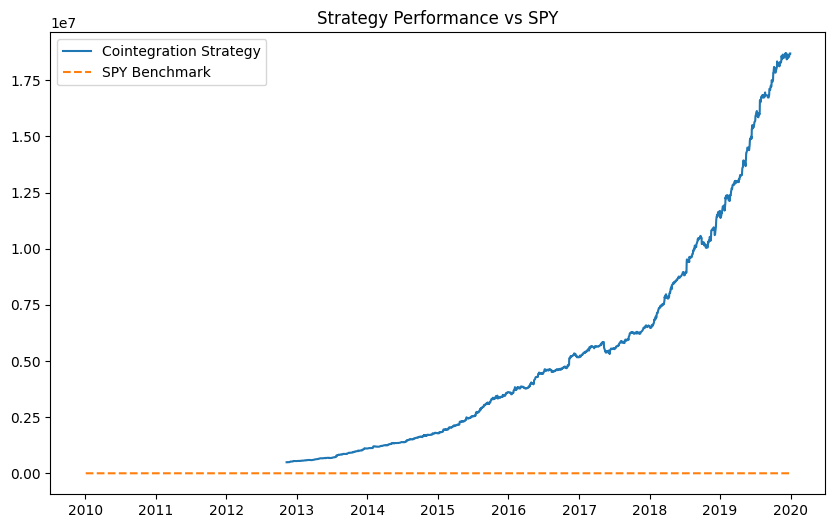

In [ ]:

# 9. Compare the performance to a benchmark (SPY)
benchmark_data = yf.download('SPY', start=start_date, end=end_date)['Close']
benchmark_returns = benchmark_data.pct_change()
benchmark_total_return = float(((benchmark_data.iloc[-1] / benchmark_data.iloc[0]) - 1)[0])
benchmark_annualized_return = float((((benchmark_data.iloc[-1] / benchmark_data.iloc[0]) **
                                (1 / len(benchmark_data)) - 1) * 252)[0])
benchmark_volatility = float((benchmark_returns.std() * np.sqrt(252))[0])
benchmark_sharpe_ratio = benchmark_annualized_return / benchmark_volatility

# Run the strategy
lookback_period = 30  # Example: 30-day rolling window
coint_pairs = compute_cointegration(stock_data, lookback_period)
strategy_signals = generate_signals(stock_data, coint_pairs, lookback_period)
portfolio_value = backtest(strategy_signals, stock_data)

# Calculate performance metrics
total_return, annualized_return, volatility, sharpe_ratio = performance_metrics(portfolio_value)

# Print results
print(f"Total Return: {total_return:.2f}")
print(f"Annualized Return: {annualized_return:.2f}")
print(f"Volatility: {volatility:.2f}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Print benchmark results
print(f"SPY Benchmark Total Return: {benchmark_total_return}")
print(f"SPY Benchmark Annualized Return: {benchmark_annualized_return:.2f}")
print(f"SPY Benchmark Volatility: {benchmark_volatility:.2f}")
print(f"SPY Benchmark Sharpe Ratio: {benchmark_sharpe_ratio:.2f}")

# Visualize the results
plot_results(portfolio_value, benchmark_data)


In [8]:
# Diagnostic cell 1: Check cointegrated pairs
print("Number of cointegrated pairs found:", len(coint_pairs))
print("\nCointegrated pairs:")
for pair in coint_pairs:
    print(f"{pair[0]} - {pair[1]}")

# Check signal statistics
print("\nSignal statistics:")
print(strategy_signals.describe())

# Check how many trading signals we get
signal_counts = (abs(strategy_signals) > 1).sum()
print("\nNumber of trading signals per pair:")
print(signal_counts)

Number of cointegrated pairs found: 9

Cointegrated pairs:
AMZN - META
AVGO - BRK-B
AVGO - GOOG
AVGO - GOOGL
AVGO - MSFT
AVGO - NVDA
GOOG - META
GOOG - NVDA
GOOGL - NVDA

Signal statistics:
         AMZN_META   AVGO_BRK-B    AVGO_GOOG   AVGO_GOOGL    AVGO_MSFT  \
count  1887.000000  1887.000000  1887.000000  1887.000000  1887.000000   
mean     -0.275400    -0.327096    -0.184115    -0.185390    -0.455062   
std       1.326914     1.320759     1.320764     1.320055     1.266510   
min      -5.115938    -4.297551    -4.565347    -4.473671    -4.504964   
25%      -1.276997    -1.364237    -1.234874    -1.241681    -1.366168   
50%      -0.445212    -0.496151    -0.238264    -0.231927    -0.667891   
75%       0.755568     0.757975     0.881746     0.863285     0.445564   
max       4.289737     4.114828     3.423354     3.441715     3.741723   

         AVGO_NVDA    GOOG_META    GOOG_NVDA   GOOGL_NVDA  
count  1887.000000  1887.000000  1887.000000  1887.000000  
mean      0.334021    -

Initial portfolio value: 500000
Final portfolio value: 18692970.599580564

Portfolio value statistics:
count    1.796000e+03
mean     5.534885e+06
std      4.888465e+06
min      4.898295e+05
25%      1.518844e+06
50%      4.425482e+06
75%      7.721364e+06
max      1.870184e+07
Name: Portfolio Value, dtype: float64


C:\Users\jairu\AppData\Local\Temp\ipykernel_13532\1786557556.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Final portfolio value:", portfolio_value[-1])


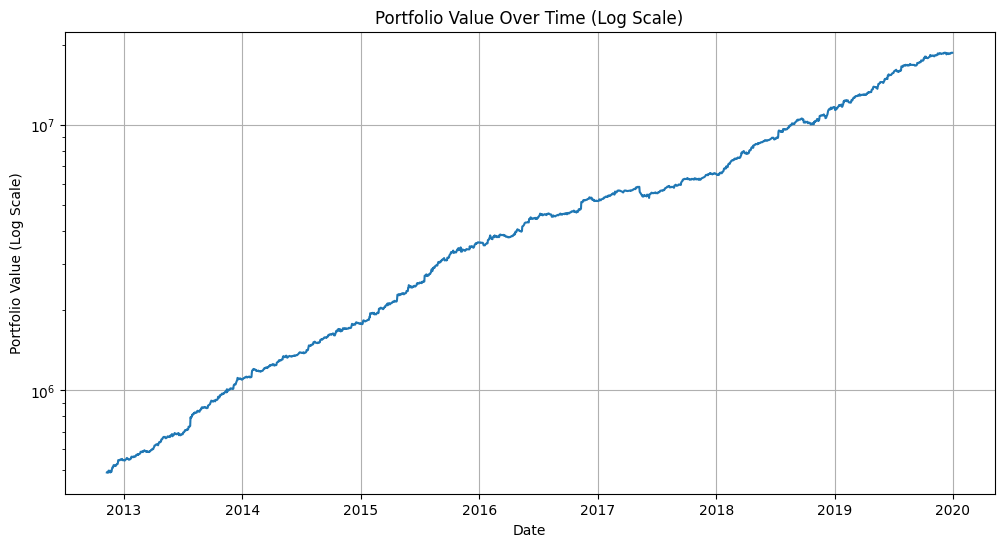


Daily returns statistics:
count    1795.000000
mean        0.002056
std         0.007319
min        -0.039729
25%        -0.001615
50%         0.001411
75%         0.004710
max         0.076937
Name: Portfolio Value, dtype: float64


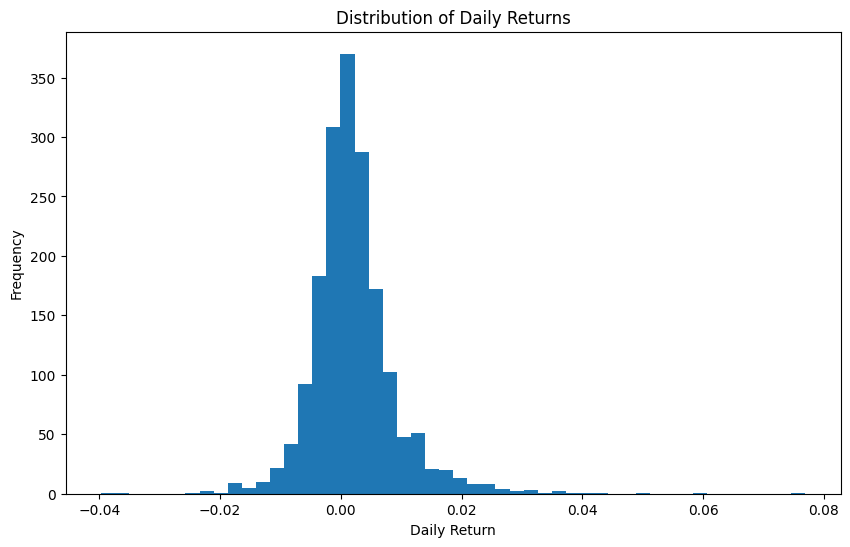

In [9]:
# Diagnostic cell 2: Check portfolio value calculations
print("Initial portfolio value:", 500000)
print("Final portfolio value:", portfolio_value[-1])
print("\nPortfolio value statistics:")
print(portfolio_value.describe())

# Plot portfolio value over time with log scale to better visualize the growth
plt.figure(figsize=(12, 6))
plt.semilogy(portfolio_value.index, portfolio_value.values)
plt.title('Portfolio Value Over Time (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Log Scale)')
plt.grid(True)
plt.show()

# Calculate daily returns and check for any extreme values
daily_returns = portfolio_value.pct_change()
print("\nDaily returns statistics:")
print(daily_returns.describe())

# Plot daily returns distribution
plt.figure(figsize=(10, 6))
plt.hist(daily_returns.dropna(), bins=50)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# --------------------
# FINAL NOTEBOOK CELL
# --------------------

# Define parameters for the backtest
start_date = "DD-MM-YYYY"
end_date = "DD-MM-YYYY"
stock_list = []
lookback_period = 30

# One function that runs the backtest
results = run_backtest()

# Display results
print(results)